# Deep Learning-Based Classification of Chest X-Ray Images for Respiratory Disease Detection
A Convolutional Neural Network Approach for Automated Medical Imaging Analysis Enabling Multi-Class Classification of COVID-19, Pneumonia, and Tuberculosis Cases Compared Against Normal Chest Radiographs for Enhanced Diagnostic Accuracy Supporting Healthcare Professionals in Early Disease Detection and Patient Care

## Import Dependences

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import cv2
import shutil
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from itertools import cycle
from sklearn.utils import resample
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D
from tensorflow.keras.layers import MaxPooling2D,BatchNormalization, Flatten
from tensorflow.keras.utils import to_categorical

## Check Versions

In [3]:
tf.__version__,cv2.__version__

('2.16.2', '4.10.0')

In [4]:
!python --version

Python 3.10.10


## Check Devices

In [5]:
print("Available devices:")
for device in tf.config.list_physical_devices():
    print(device)

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')


## Load Dataset

In [6]:

# Define paths
base_dir = r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset"
output_dir = r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data"
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "validation")
test_dir = os.path.join(output_dir, "test")

# Classes (folder names)
classes = ["Covid", "Normal", "Pneumonia", "Tuberculosis"]

# Split ratios
test_size = 0.1   # 10% test
val_size = 0.1    # 10% validation
# train_size = 0.8  # 80% train (remaining)

# Create directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in classes:
    # Make class subdirectories in train, validation & test
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)
    
    # Get all images for this class
    src_dir = os.path.join(base_dir, cls)
    images = [f for f in os.listdir(src_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    # First split: separate test set (10%)
    train_val_imgs, test_imgs = train_test_split(
        images, 
        test_size=test_size, 
        random_state=42
    )
    
    # Second split: separate validation from remaining data
    # val_size / (1 - test_size) gives us 10% of original data for validation
    val_ratio = val_size / (1 - test_size)
    train_imgs, val_imgs = train_test_split(
        train_val_imgs, 
        test_size=val_ratio, 
        random_state=42
    )
    
    # Copy images to respective folders
    for img in train_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(train_dir, cls, img))
    
    for img in val_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(val_dir, cls, img))
    
    for img in test_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(test_dir, cls, img))
    
    print(f"{cls}: Total={len(images)}, Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")

print("\nData splitting completed!")
print(f"Train directory: {train_dir}")
print(f"Validation directory: {val_dir}")
print(f"Test directory: {test_dir}")

Covid: Total=18011, Train=14407, Val=1802, Test=1802
Normal: Total=18096, Train=14476, Val=1810, Test=1810
Pneumonia: Total=18187, Train=14549, Val=1819, Test=1819
Tuberculosis: Total=18002, Train=14400, Val=1801, Test=1801

Data splitting completed!
Train directory: C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\train
Validation directory: C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\validation
Test directory: C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test


In [8]:
train_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\train'
valid_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\validation'
test_path  = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test'

## Data Visualization

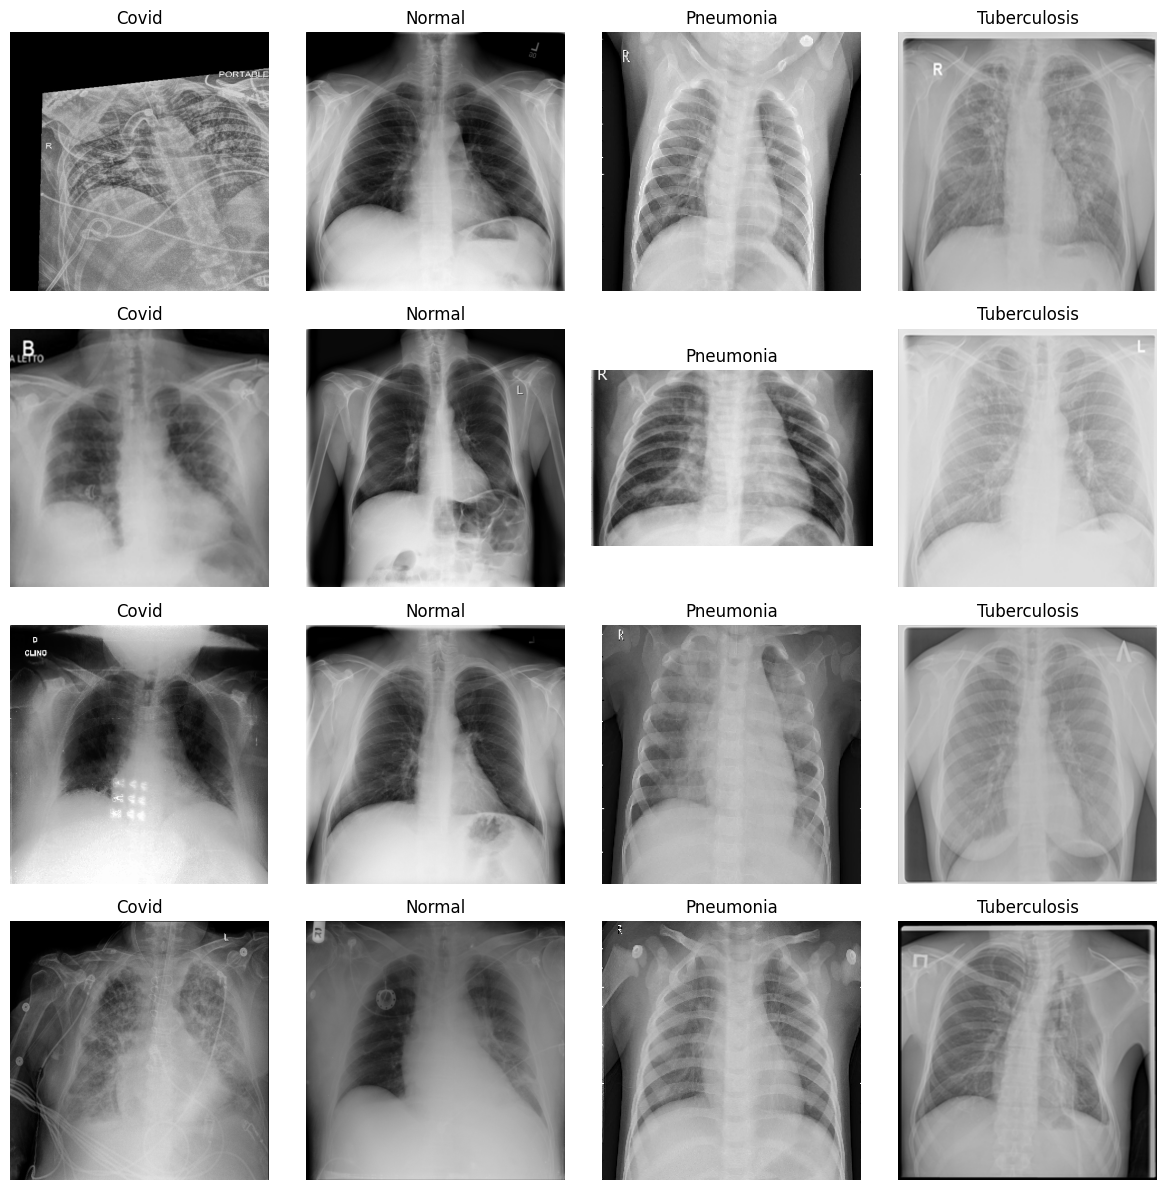

In [9]:
main_folder = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\train'
subfolders = [f for f in os.listdir(main_folder) if os.path.isdir(os.path.join(main_folder, f))]

# Get images grouped by folder
folder_images = {}
for folder in subfolders:
    path = os.path.join(main_folder, folder)
    images = [os.path.join(path, img) for img in os.listdir(path) 
              if img.endswith(('.jpg', '.png', '.webp'))]
    random.shuffle(images)  # Shuffle images within each folder
    folder_images[folder] = images

# Round-robin selection
selected_images = []
folder_cycle = cycle(subfolders)  # Infinite loop through folders
while len(selected_images) < 16:
    folder = next(folder_cycle)
    if folder_images[folder]:  # If folder still has images
        selected_images.append(folder_images[folder].pop())

# Plot them
plt.figure(figsize=(12, 12))
for i, img_path in enumerate(selected_images):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(os.path.basename(os.path.dirname(img_path)))  # Show folder name
plt.tight_layout()
plt.show()

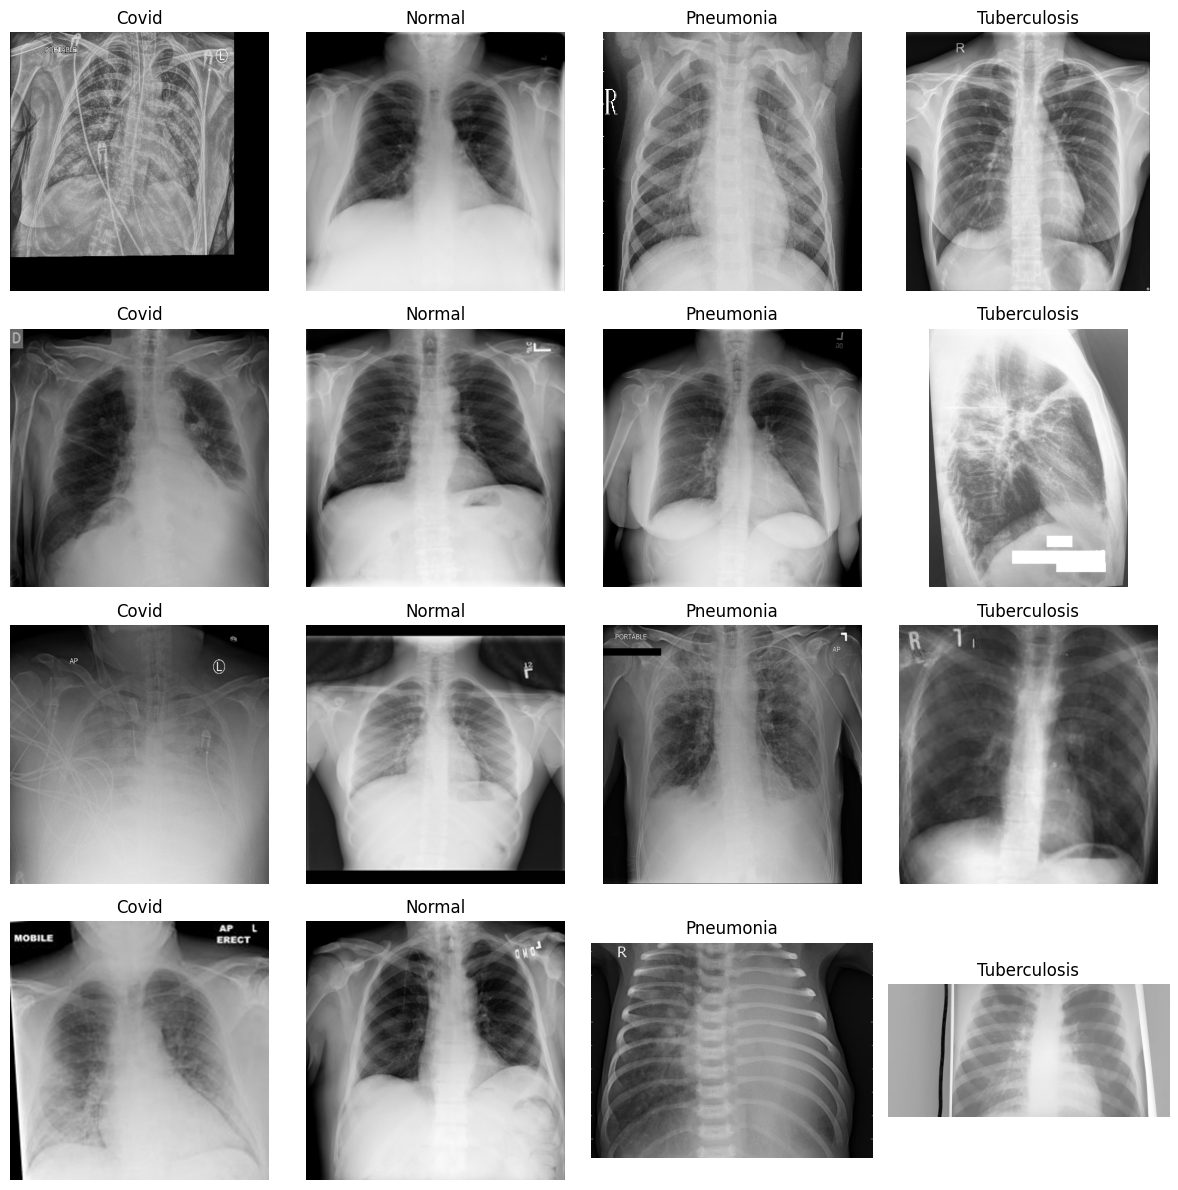

In [10]:
main_folder = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\validation'
subfolders = [f for f in os.listdir(main_folder) if os.path.isdir(os.path.join(main_folder, f))]

# Get images grouped by folder
folder_images = {}
for folder in subfolders:
    path = os.path.join(main_folder, folder)
    images = [os.path.join(path, img) for img in os.listdir(path) 
              if img.endswith(('.jpg', '.png', '.webp'))]
    random.shuffle(images)  # Shuffle images within each folder
    folder_images[folder] = images

# Round-robin selection
selected_images = []
folder_cycle = cycle(subfolders)  # Infinite loop through folders
while len(selected_images) < 16:
    folder = next(folder_cycle)
    if folder_images[folder]:  # If folder still has images
        selected_images.append(folder_images[folder].pop())

# Plot them
plt.figure(figsize=(12, 12))
for i, img_path in enumerate(selected_images):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(os.path.basename(os.path.dirname(img_path)))  # Show folder name
plt.tight_layout()
plt.show()

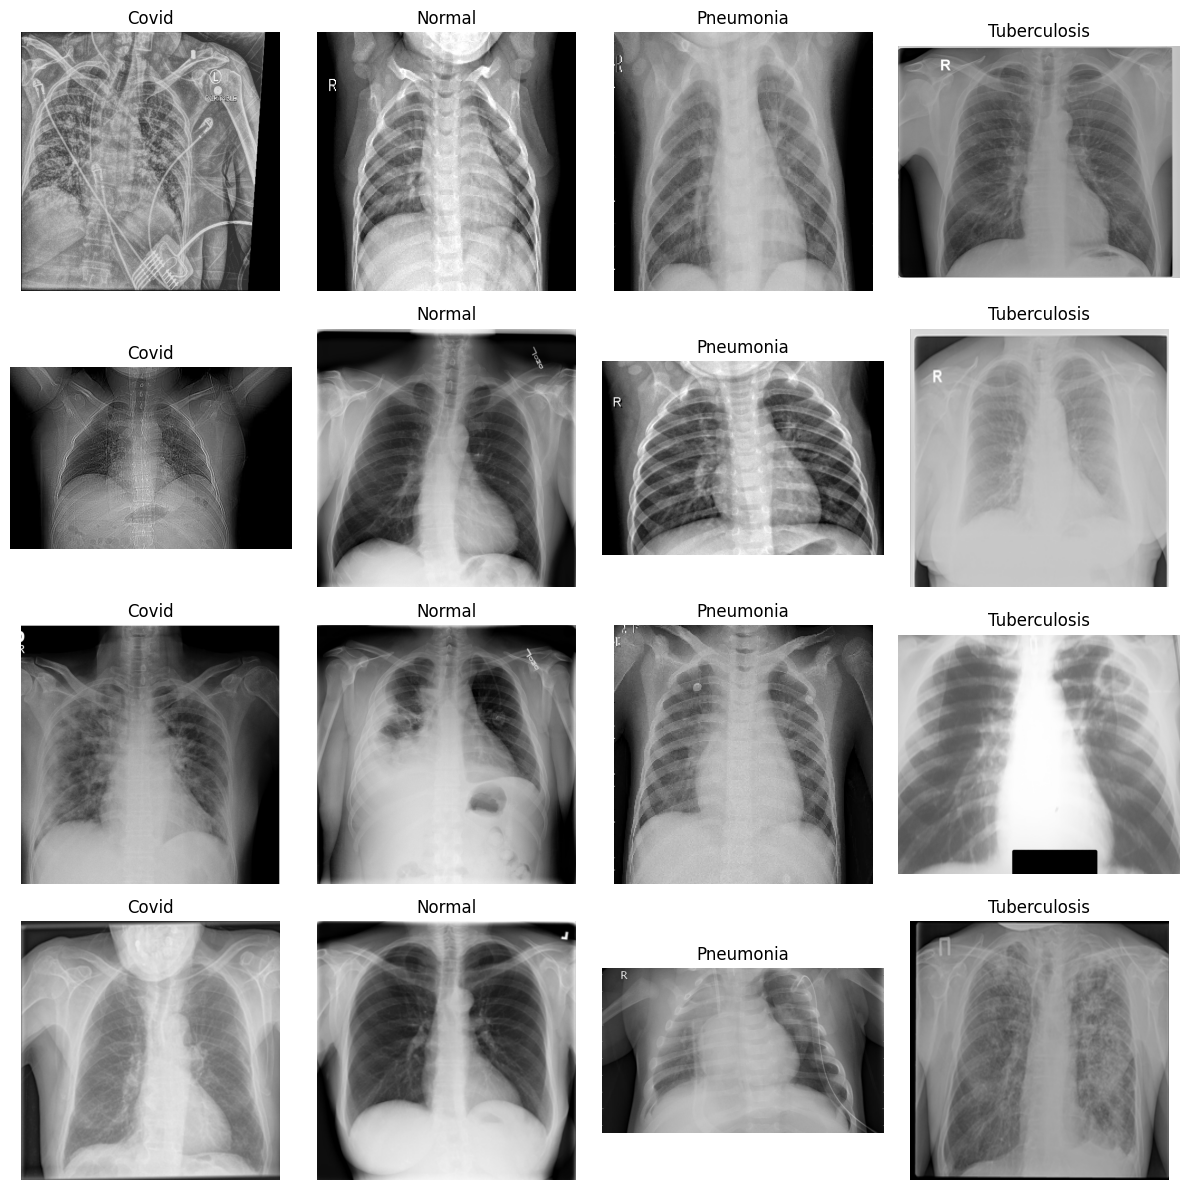

In [11]:
main_folder = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test'
subfolders = [f for f in os.listdir(main_folder) if os.path.isdir(os.path.join(main_folder, f))]

# Get images grouped by folder
folder_images = {}
for folder in subfolders:
    path = os.path.join(main_folder, folder)
    images = [os.path.join(path, img) for img in os.listdir(path) 
              if img.endswith(('.jpg', '.png', '.webp'))]
    random.shuffle(images)  # Shuffle images within each folder
    folder_images[folder] = images

# Round-robin selection
selected_images = []
folder_cycle = cycle(subfolders)  # Infinite loop through folders
while len(selected_images) < 16:
    folder = next(folder_cycle)
    if folder_images[folder]:  # If folder still has images
        selected_images.append(folder_images[folder].pop())

# Plot them
plt.figure(figsize=(12, 12))
for i, img_path in enumerate(selected_images):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(os.path.basename(os.path.dirname(img_path)))  # Show folder name
plt.tight_layout()
plt.show()

## Data Preprocessing

In [12]:
IMAGE_SIZE = 224

BATCH_SIZE = 32

In [13]:
def cnn_preprocess(x):
    return x/255.0

In [14]:
cnn_train_datagen = ImageDataGenerator(preprocessing_function=cnn_preprocess)
cnn_train_generator = cnn_train_datagen.flow_from_directory(
        train_path,
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical')

Found 57832 images belonging to 4 classes.


In [16]:
cnn_train_generator.class_indices

{'Covid': 0, 'Normal': 1, 'Pneumonia': 2, 'Tuberculosis': 3}

In [17]:
cnn_valid_datagen = ImageDataGenerator(preprocessing_function=cnn_preprocess)
cnn_valid_generator = cnn_valid_datagen.flow_from_directory(
        valid_path,
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical')

Found 7232 images belonging to 4 classes.


In [18]:
cnn_valid_generator.class_indices

{'Covid': 0, 'Normal': 1, 'Pneumonia': 2, 'Tuberculosis': 3}

In [19]:
cnn_test_datagen = ImageDataGenerator(preprocessing_function=cnn_preprocess)
cnn_test_generator = cnn_test_datagen.flow_from_directory(
        test_path,
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical')

Found 7232 images belonging to 4 classes.


In [20]:
cnn_test_generator.class_indices

{'Covid': 0, 'Normal': 1, 'Pneumonia': 2, 'Tuberculosis': 3}

## CNN Model Building

In [21]:
cnn_model = keras.Sequential([
    keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dense(units=64, activation='relu'),

    keras.layers.Dense(units=len(cnn_test_generator.class_indices), activation='softmax', dtype='float32')
])

In [23]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,200,964 (42.73 MB)

 Trainable params: 11,200,964 (42.73 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',    
        patience=5,             
        restore_best_weights=True
    ),
    
    ModelCheckpoint(
        filepath='CNN_best_model.keras',  
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False, 
        mode='min',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [25]:
cnn_model.compile(optimizer=keras.optimizers.Adam(), 
              loss=keras.losses.CategoricalCrossentropy(), 
               metrics=['accuracy',keras.metrics.Precision(name='precision'),
                        keras.metrics.Recall(name='recall'),
                        keras.metrics.F1Score(name='f1_score')
])

In [26]:
cnn_history = cnn_model.fit(
        cnn_train_generator,
        epochs = 20,
        validation_data = cnn_valid_generator,
        callbacks = callbacks
        )

Epoch 1/20
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7661 - f1_score: 0.7646 - loss: 0.6028 - precision: 0.8295 - recall: 0.6965
Epoch 1: val_loss improved from inf to 0.28811, saving model to CNN_best_model.keras
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 2362s 1s/step - accuracy: 0.7661 - f1_score: 0.7646 - loss: 0.6027 - precision: 0.8295 - recall: 0.6966 - val_accuracy: 0.8957 - val_f1_score: 0.8963 - val_loss: 0.2881 - val_precision: 0.9108 - val_recall: 0.8841 - learning_rate: 0.0010
Epoch 2/20
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.9087 - f1_score: 0.9090 - loss: 0.2611 - precision: 0.9222 - recall: 0.8964
Epoch 2: val_loss improved from 0.28811 to 0.24153, saving model to CNN_best_model.keras
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 1829s 1s/step - accuracy: 0.9087 - f1_score: 0.9090 - loss: 0.2611 - precision: 0.9223 - recall: 0.8964 - val_accuracy: 0.9204 - val_f1_score: 0.9205 - val_loss: 0.2415 - val_precision: 0.9308 - val_recall: 0.9110 - learning_rate: 0.0010

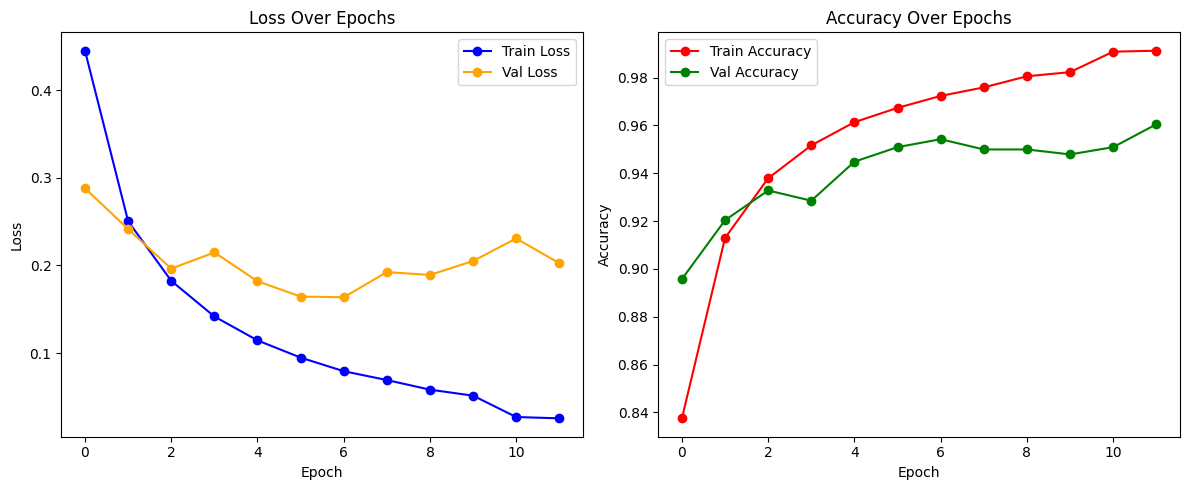

In [27]:
# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# 📉 Loss
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(cnn_history.history['val_loss'], label='Val Loss', marker='o', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 📈 Accuracy
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy', marker='o', color='red')
plt.plot(cnn_history.history['val_accuracy'], label='Val Accuracy', marker='o', color='green')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Model performance testing

In [28]:
cnn_predictions = cnn_model.predict(cnn_test_generator)

226/226 ━━━━━━━━━━━━━━━━━━━━ 169s 750ms/step


In [29]:
cnn_result = cnn_model.evaluate(cnn_test_generator, batch_size=BATCH_SIZE)

226/226 ━━━━━━━━━━━━━━━━━━━━ 101s 445ms/step - accuracy: 0.9522 - f1_score: 0.9520 - loss: 0.1608 - precision: 0.9538 - recall: 0.9506


In [30]:
history = {
    "CNN": {"accuracy": cnn_history.history['accuracy'],
            "val_accuracy": cnn_history.history['val_accuracy'] ,
            "loss": cnn_history.history['loss'],"val_loss": cnn_history.history['val_loss']}}

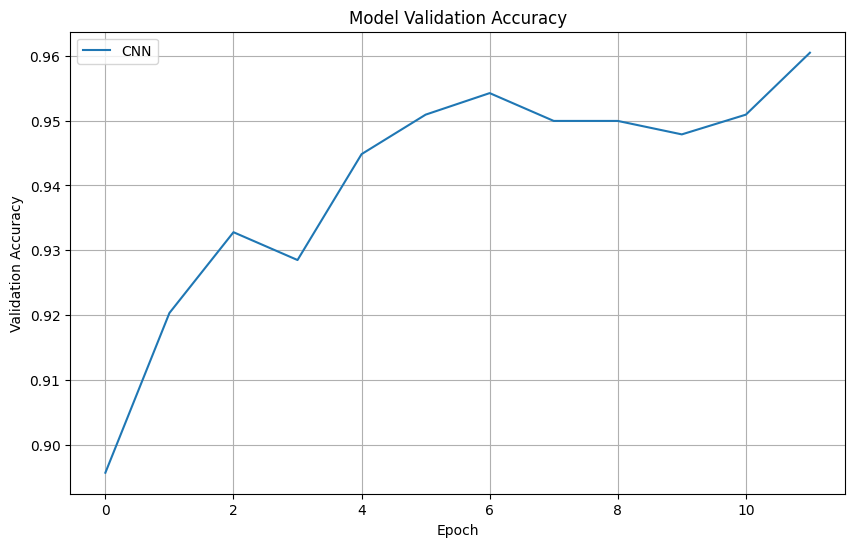

In [31]:
plt.figure(figsize=(10, 6))
for model, values in history.items():
    plt.plot(values['val_accuracy'], label=model)
plt.title('Model Validation Accuracy')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

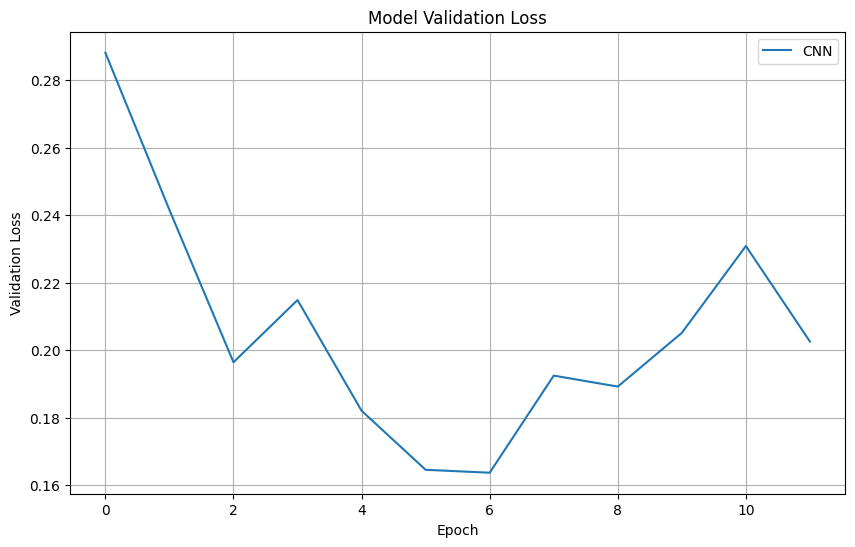

In [32]:
plt.figure(figsize=(10, 6))
for model, values in history.items():
    plt.plot(values['val_loss'], label=model)
plt.title('Model Validation Loss')
plt.ylabel('Validation Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

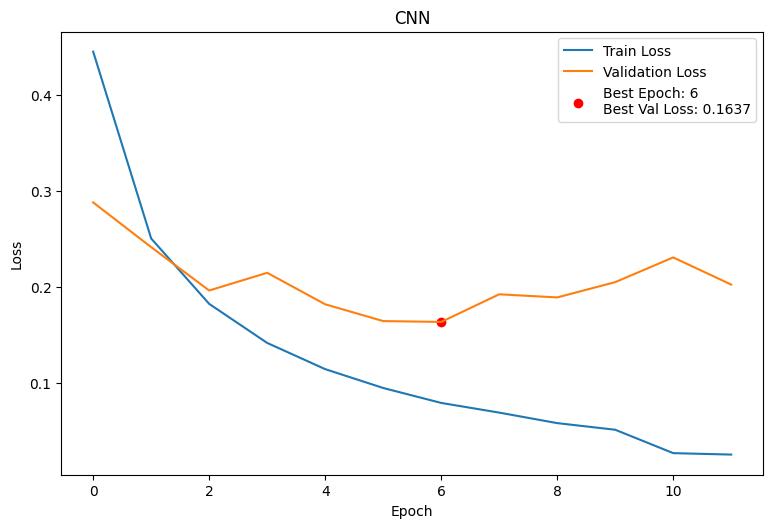

In [33]:
plt.figure(figsize=(15, 20))

# Sort models by least validation loss
sorted_models = sorted(history.items(), key=lambda x: min(x[1]['val_loss']))

# Plot each model based on sorted order of least val_loss
for i, (model_name, model_history) in enumerate(sorted_models, 1):
    plt.subplot(4, 2, i) 
    plt.plot(model_history['loss'], label='Train Loss')
    plt.plot(model_history['val_loss'], label='Validation Loss')

    # Find the best epoch based on least val_loss
    min_val_loss_epoch = model_history['val_loss'].index(min(model_history['val_loss']))
    min_val_loss = min(model_history['val_loss'])

    plt.scatter(min_val_loss_epoch, min_val_loss, color='red', label=f'Best Epoch: {min_val_loss_epoch}\nBest Val Loss: {min_val_loss:.4f}')

    plt.title(model_name)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

plt.tight_layout()
plt.show()

Accuracy values:
CNN: 0.9535


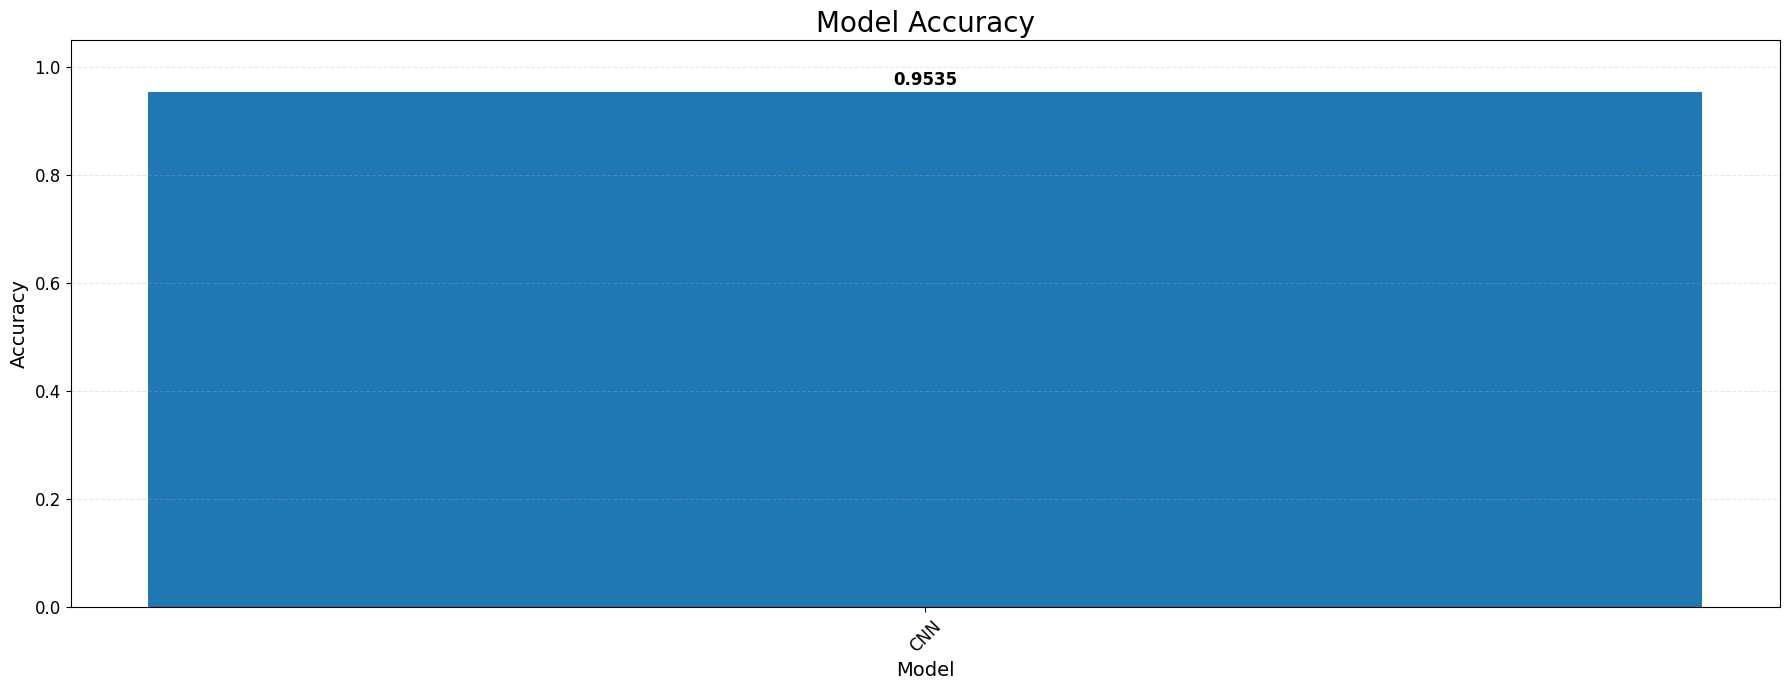

In [34]:
THE_ALL_RESULTS = {
    'CNN': cnn_result[1]
}

print("Accuracy values:")
for model, accuracy in THE_ALL_RESULTS.items():
    print(f"{model}: {accuracy:.4f}")

plt.figure(figsize=(18, 7))
bars = plt.bar(THE_ALL_RESULTS.keys(), THE_ALL_RESULTS.values(), 
               color=['#1f77b4'])

# Add value labels on top of each bar
for bar, (model, accuracy) in zip(bars, THE_ALL_RESULTS.items()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{accuracy:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Set y-axis limits to better show differences
plt.ylim(0, max(THE_ALL_RESULTS.values()) * 1.1)

plt.tight_layout()
plt.show()

In [1]:
from tensorflow.keras.models import load_model

model = load_model("Brave.keras")   # or full path if needed
print("Model loaded ✅")

Model loaded ✅


In [5]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\Normal\000db696-cf54-4385-b10b-6b16fbb3f985.png", target_size=(224, 224))
img_array = image.img_to_array(img)

img_array.shape

(224, 224, 3)

In [6]:
img_array.shape

(224, 224, 3)

In [12]:
!pip install tabulate

In [7]:
63import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ----------------------------
# 1️⃣ Evaluation Generators (Rescale only, shuffle=False)
# ----------------------------

train_eval_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
     r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Important!
)

val_eval_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\validation",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_eval_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ----------------------------
# 2️⃣ Evaluation Function
# ----------------------------
def evaluate_generator(model, generator, set_name="Set"):
    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    
    accuracy = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(y_true, y_pred, average='weighted') * 100
    recall = recall_score(y_true, y_pred, average='weighted') * 100
    f1 = f1_score(y_true, y_pred, average='weighted') * 100
    
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Value': [f"{accuracy:.2f}%", f"{precision:.2f}%", f"{recall:.2f}%", f"{f1:.2f}%"]
    })
    
    print(f"\n### {set_name} Performance\n")
    print(metrics_df)
    
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_df = pd.DataFrame(conf_matrix,
                           index=[f"Class {i}" for i in range(conf_matrix.shape[0])],
                           columns=[f"Class {i}" for i in range(conf_matrix.shape[1])])
    print(f"\n### {set_name} Confusion Matrix\n")
    print(conf_df)

# ----------------------------
# 3️⃣ Evaluate All Sets
# ----------------------------
evaluate_generator(model, train_eval_generator, set_name="Training Set")
evaluate_generator(model, val_eval_generator, set_name="Validation Set")
evaluate_generator(model, test_eval_generator, set_name="Test Set")

Found 57832 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.


C:\Users\hp\Desktop\Brave_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1808/1808 ━━━━━━━━━━━━━━━━━━━━ 1028s 568ms/step

### Training Set Performance

      Metric   Value
0   Accuracy  98.72%
1  Precision  98.73%
2     Recall  98.72%
3   F1 Score  98.71%

### Training Set Confusion Matrix

         Class 0  Class 1  Class 2  Class 3
Class 0    14376        7        7       17
Class 1       90    14271       71       44
Class 2       78      363    14107        1
Class 3       20       43        2    14335


C:\Users\hp\Desktop\Brave_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


226/226 ━━━━━━━━━━━━━━━━━━━━ 130s 575ms/step

### Validation Set Performance

      Metric   Value
0   Accuracy  95.42%
1  Precision  95.47%
2     Recall  95.42%
3   F1 Score  95.42%

### Validation Set Confusion Matrix

         Class 0  Class 1  Class 2  Class 3
Class 0     1759       17        8       18
Class 1       49     1706       31       24
Class 2       31       96     1685        7
Class 3       19       25        6     1751


C:\Users\hp\Desktop\Brave_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


226/226 ━━━━━━━━━━━━━━━━━━━━ 128s 566ms/step

### Test Set Performance

      Metric   Value
0   Accuracy  95.35%
1  Precision  95.41%
2     Recall  95.35%
3   F1 Score  95.35%

### Test Set Confusion Matrix

         Class 0  Class 1  Class 2  Class 3
Class 0     1760       19        8       15
Class 1       61     1698       28       23
Class 2       30       82     1691       16
Class 3       29       24        1     1747


In [9]:
import tensorflow as tf

for name, val in list(globals().items()):
    if isinstance(val, tf.keras.Model):
        print("FOUND MODEL:", name)

FOUND MODEL: model


In [11]:
model.save("Brave.keras")
print("Model saved successfully ✅")

Model saved successfully ✅


In [1]:
from tensorflow.keras.models import load_model

model = load_model("Brave.keras")   # or full path if needed
print("Model loaded ✅")

Model loaded ✅


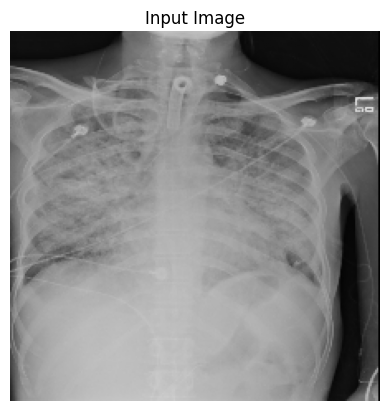

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
✅ Prediction: Normal
✅ Confidence: 70.10%


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- LOAD IMAGE ---
image_path = r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test\Normal\000fe35a-2649-43d4-b027-e67796d412e0.png"
img = cv2.imread(image_path)
if img is None:
    raise ValueError("❌ Image not found. Check the file path.")

# --- PREPROCESS (MATCH TRAINING) ---
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # convert to RGB
img = cv2.resize(img, (224, 224))            # resize
img = img / 255.0                            # normalize
img = img.reshape(1, 224, 224, 3)             # batch + 3 channels

# --- SHOW IMAGE ---
plt.imshow(img[0])
plt.axis("off")
plt.title("Input Image")
plt.show()

# --- PREDICT ---
prediction = model.predict(img)

# --- CLASS NAMES (adjust if needed) ---
classes = ["Covid", "Normal", "Pneumonia", "Tuberculosis"]

class_idx = np.argmax(prediction)
confidence = np.max(prediction)

print("✅ Prediction:", classes[class_idx])
print(f"✅ Confidence: {confidence * 100:.2f}%")